트포 오랜만...

## <span style="background-color:#ffdef1; color:#ff009b; padding:4px; border-radius:5px;"> Attention의 등장 배경 </span>

결국 기울기 소실...

##### <span style="background-color:#c9cfff; color:#000b6e; padding:4px; border-radius:5px;"> RNN </span>

이 놈은 장기 의존성 문제 때문에 기울기 소실 혹은 폭주

##### <span style="background-color:#c9cfff; color:#000b6e; padding:4px; border-radius:5px;"> LSTM </span>

중요 정보를 다시 cell state에 넣지만 그럼에도 초반 정보가 forget gate에 들어갈 확률 높아서 또 정보 손실...

### <span style="background-color:#ccffd0; color:#0b8c16; padding:4px; border-radius:5px;"> Attention </span>
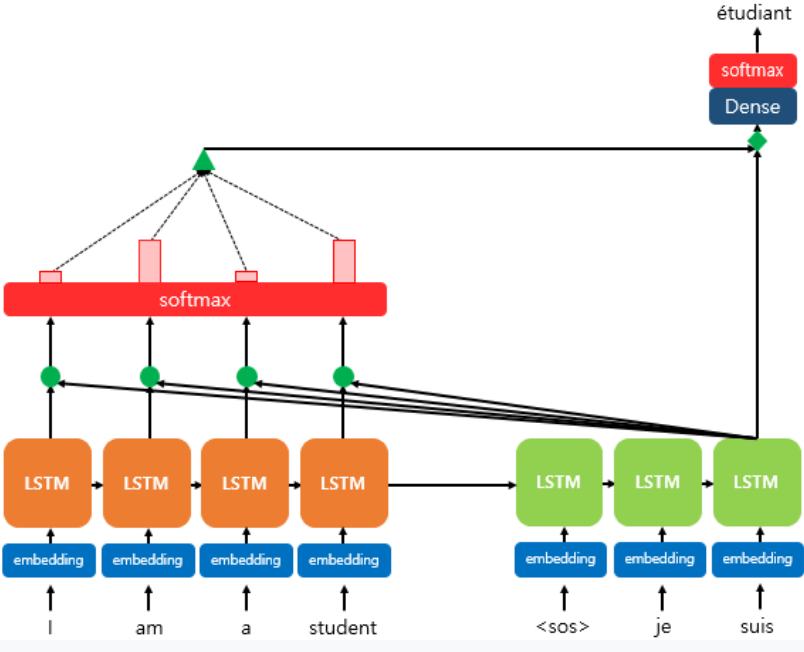

출력 시점마다 새로운 의미 벡터를 계산하기 때문에 병렬적 처리 -> 시간/위치로 인한 제한 x -> 정보 손실 줄이고 중요한 정보에 더 집중하자!

그럼에도 아직 인코더 디코더를 RNN, LSTM 쓰는데........


쓰지 말고 걍 어텐션으로 모든 걸 하자 -> 트.포

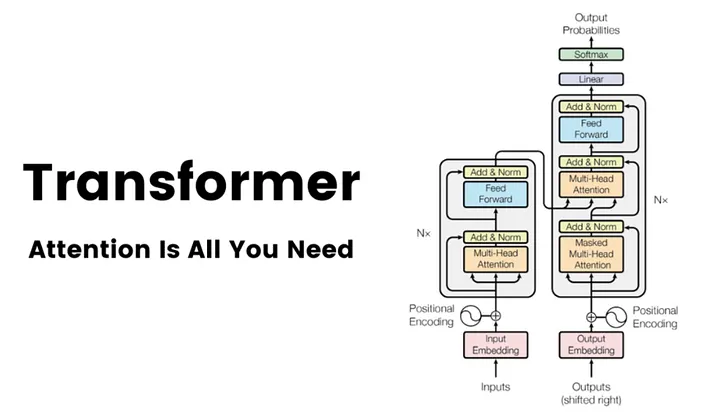

##### <span style="background-color:#c9cfff; color:#000b6e; padding:4px; border-radius:5px;"> 트포의 핵심 </span>

1. **Self-Attention** :문장 안에서 어떤 단어가 다른 단어들과 얼마나 중요한 관계를 맺고 있는지
2. **Multi-Head Attention** : 셀프 어텐션을 여러 head에서 병럴 처리
3. **Positional Encoding** : 단어의 위치 정보를 벡터에 추가하여 각 단어가 문장의 몇 번째 위치에 존재하는지 알 수 ㅇ

## <span style="background-color:#ffdef1; color:#ff009b; padding:4px; border-radius:5px;"> Self Attention </span>

### <span style="background-color:#ccffd0; color:#0b8c16; padding:4px; border-radius:5px;"> Query, Key, Value</span>

##### <span style="background-color:#c9cfff; color:#000b6e; padding:4px; border-radius:5px;"> 쿼리 </span>
> 질문 또는 요청 (내가 초점을 맞춘 대상)

##### <span style="background-color:#c9cfff; color:#000b6e; padding:4px; border-radius:5px;"> 키 </span>
> 검색 대상이 되는 모든 정보가 달고 있는 색인

##### <span style="background-color:#c9cfff; color:#000b6e; padding:4px; border-radius:5px;"> 쿼리 </span>
> 키와 쌍이 되는 실제 내용

### <span style="background-color:#ccffd0; color:#0b8c16; padding:4px; border-radius:5px;"> Cross Attention과의 차이 </span>
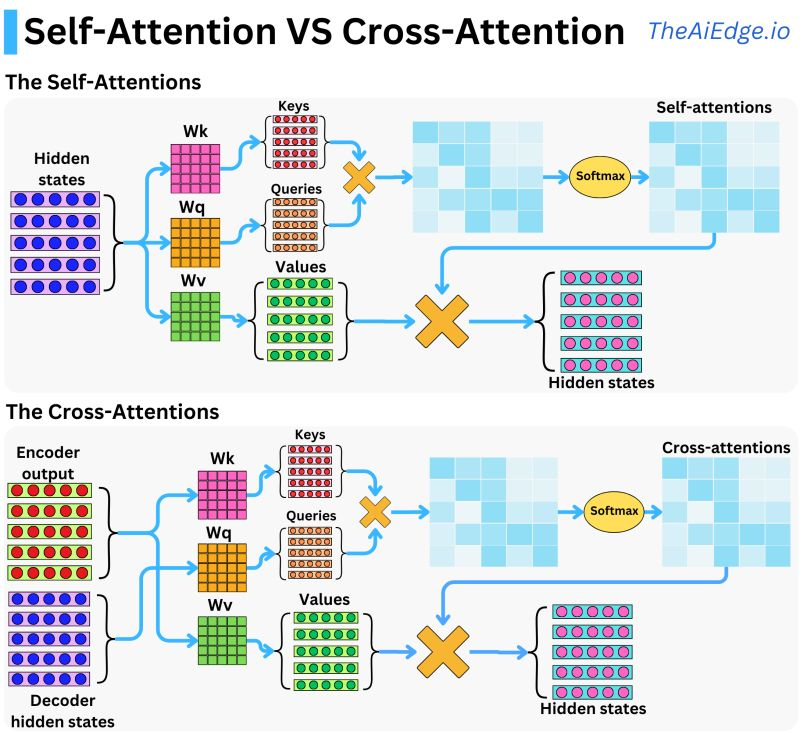

크로스 어텐션(트포 디코더에 쓰임)은 아웃풋도 슬쩍슬쩍 참고하기 때문에 순차적, 셀프 어텐션은 시퀀스 자체의 문맥에 의존함 (디코더의 한계...)

### <span style="background-color:#ccffd0; color:#0b8c16; padding:4px; border-radius:5px;"> Scaled Dot-Product Attention </span>

기존 내적 어텐션:
쿼리와 키 벡터 내적 -> 어텐션 스코어(가중치) 계산

이러니까 차원 커질수록 기울기 소실 문제 발생 가능...

-> 스케일링하자...

나누고 소프트맥스 적용해서 어텐션 가중치를 총합 1이 되게 함


- RNN의 한계
    - Attention의 등장 배경 및 장점
    - Attention is All You Need
- Self-Attention
    - Query, Key, Value 개념
    - Cross Attention vs. Self-Attention 개념 및 과정
    - Scaled Dot-Product Attention
- Multi-Head Attention
    - Multi-Head Attention 개념
    - Multi-Head Attention 작동 방식
- Transformer 전체 아키텍처
    - 전처리 단계(토큰화 - 임베딩 - Positional Encoding)
    - Encoder와 Decoder

## <span style="background-color:#ffdef1; color:#ff009b; padding:4px; border-radius:5px;"> Multi-Head Attention </span>

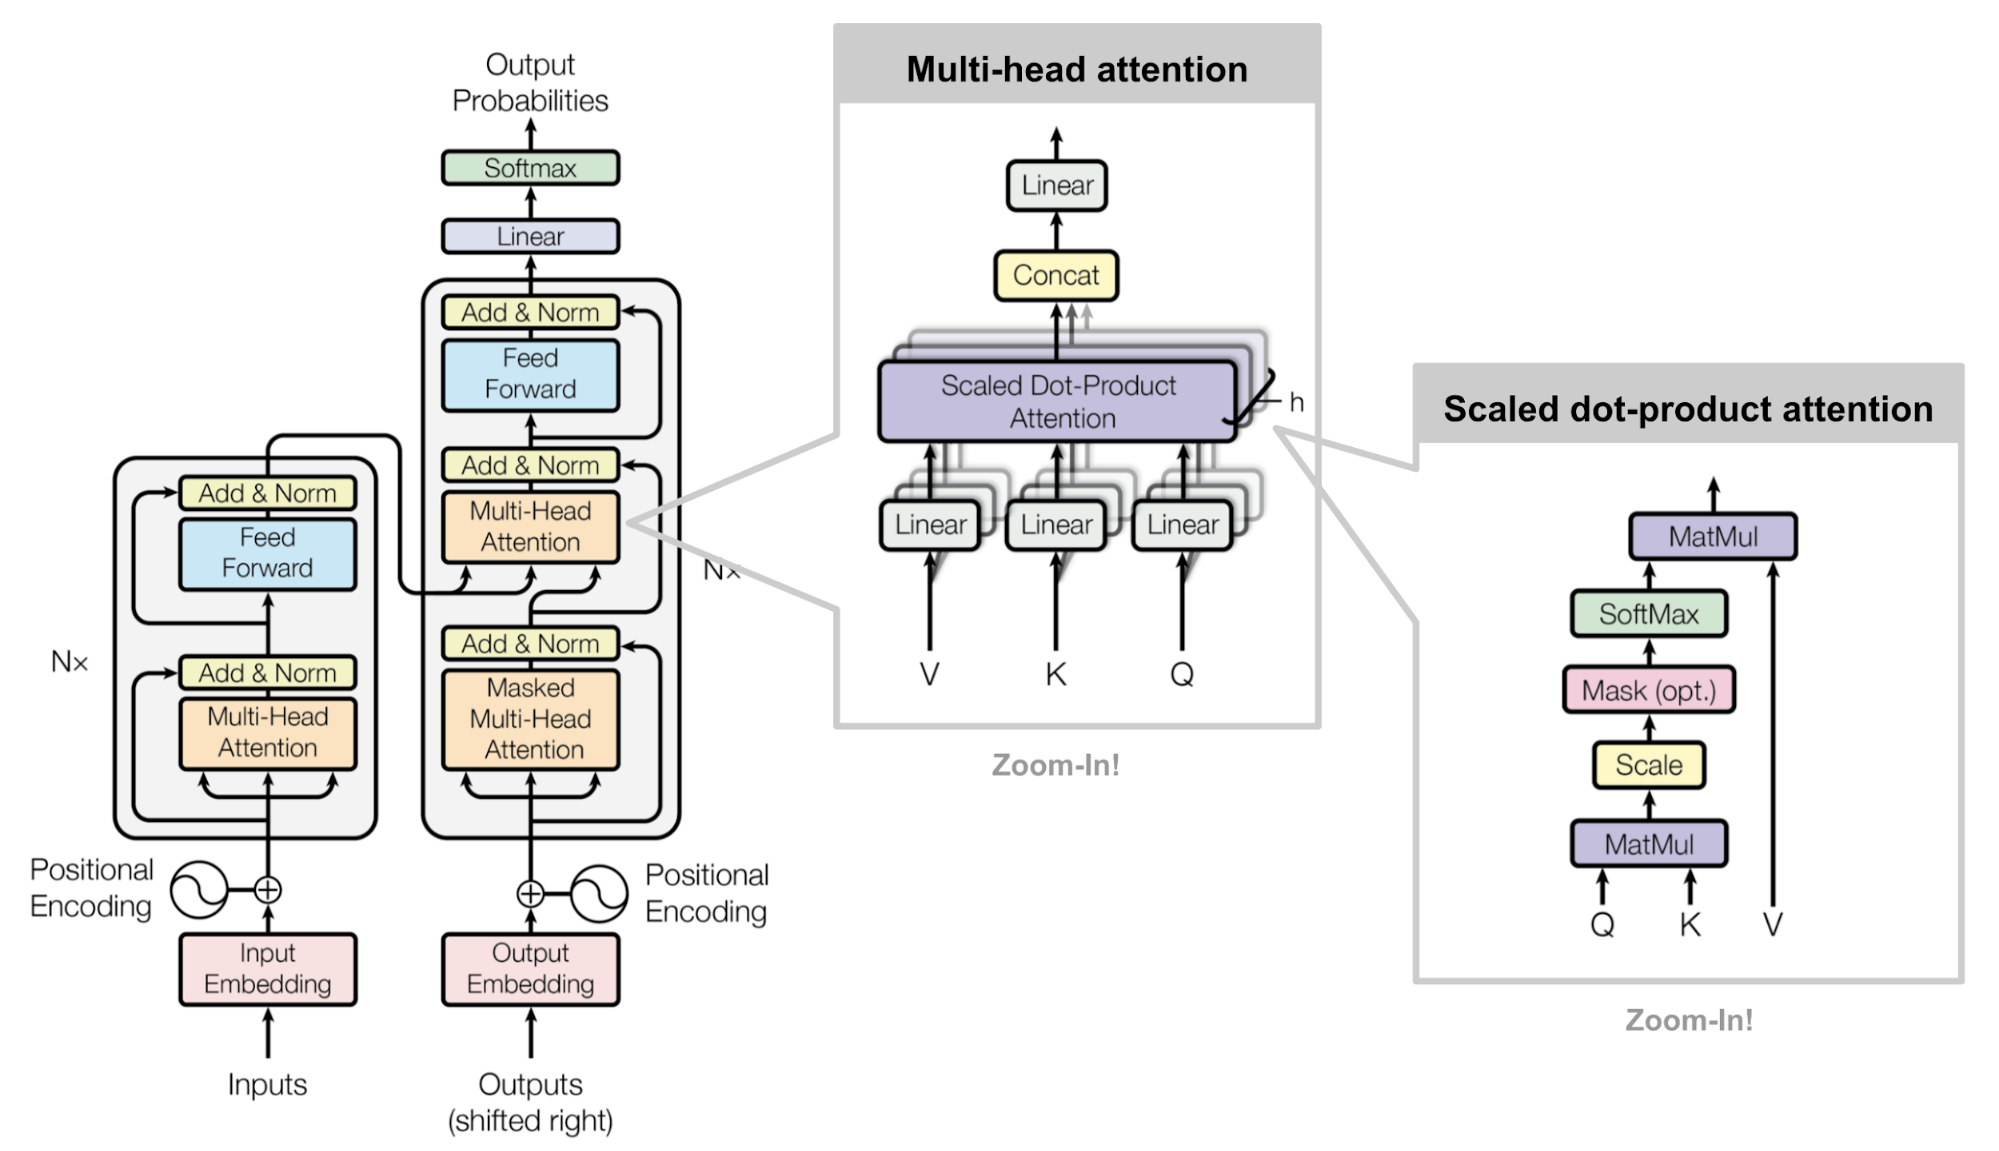

각기 다른 관점의 헤드(문법, 의미, 위치 등등)로 나눠서 문장 내 단어 간의 관계를 병렬적으로 처리!

1. 쿼리 단어와 키 단어(문장 내 다른 단어)들과의 어텐션 점수 계산
2. 스케일링
3. 소프트맥스로 총합 1인 가중치로 변환
4. value 벡터에 가중치를 곱하고 모두 더함
5. 각 헤드에서 계산된 어텐션 가중치를 결합하고, 가중치 행렬을 곱해서 최종 반영

## <span style="background-color:#ffdef1; color:#ff009b; padding:4px; border-radius:5px;"> 트포 아키텍처 </span>

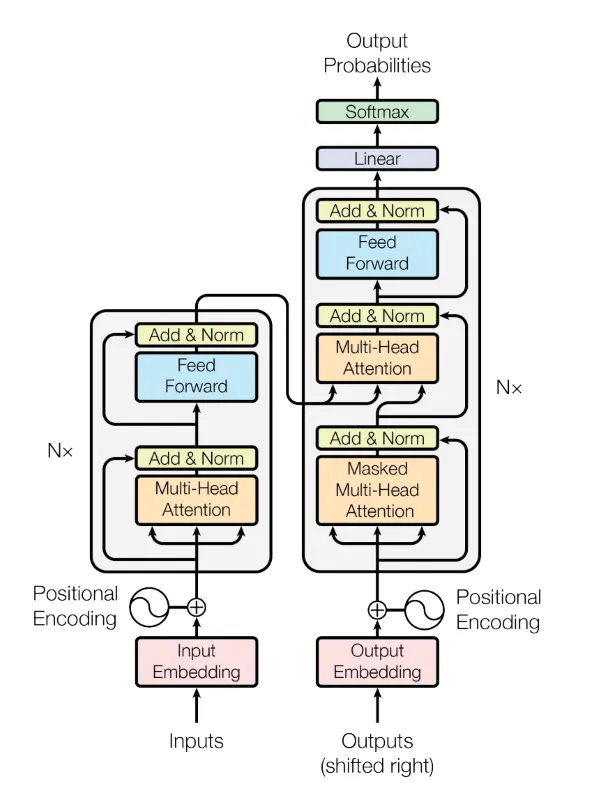

### <span style="background-color:#ccffd0; color:#0b8c16; padding:4px; border-radius:5px;"> 전처리 </span>

##### <span style="background-color:#c9cfff; color:#000b6e; padding:4px; border-radius:5px;"> 토큰화 </span>

입력 문장을 토큰 단위로 나눔

##### <span style="background-color:#c9cfff; color:#000b6e; padding:4px; border-radius:5px;"> 임베딩 </span>

각 토큰을 벡터 차원으로 표현

##### <span style="background-color:#c9cfff; color:#000b6e; padding:4px; border-radius:5px;"> Postional Encoding </span>

트포는 토큰을 병렬 처리하기 때문에 순서 정보 x -> 따라서 순서에 따른 벡터를 임베딩 벡터에 적용하여 변환

### <span style="background-color:#ccffd0; color:#0b8c16; padding:4px; border-radius:5px;"> 인코더 </span>

##### <span style="background-color:#c9cfff; color:#000b6e; padding:4px; border-radius:5px;"> Feed-Forward Layer </span>

> 다층 퍼셉트론이 완전 연결된 구조 (단어 심층 분석)

##### <span style="background-color:#c9cfff; color:#000b6e; padding:4px; border-radius:5px;"> 잔차 연결 </span>

> 출력에 입력값 전달해서 기울기 소실 및 폭주 현상 막음

### <span style="background-color:#ccffd0; color:#0b8c16; padding:4px; border-radius:5px;"> 디코더 </span>

##### <span style="background-color:#c9cfff; color:#000b6e; padding:4px; border-radius:5px;"> Masked Multi-Head Attention </span>

> 미래 시점의 단어 정보를 참고하지 못하도록 마스크 씌움

(데이터 누수 방지와 비슷...)

##### <span style="background-color:#c9cfff; color:#000b6e; padding:4px; border-radius:5px;"> 크로스 어텐션 </span>

> 디코더의 이전 서브레이어 출력해서 순서와 맥락 참고...

~ 직접 강의 자료 제작한 부분이라 더 잘 알기도 해서, 간단히 요약 정리만 했습니다 ~